# Trabalho 3

### Dupla

Andreina Maria Mendes da Silva - 485306  
Augusto César Araújo de Oliveira - 508991

## Descrição do Trabalho

- Preparação dos dados:
  - Baixar e explorar o conjunto de dados escolhido
  - Dividir o conjunto de dados em treino, validação e teste
  - Realizar pré-processamento adequado ao tipo de dados
- Criação do modelo:
  - Projetar uma arquitetura de rede neural apropriada para o tipo de dado escolhido.
- Treinamento:
  - Implementar o loop de treinamento
  - Escolher otimizador e função de perda adequados
  - Treinar o modelo por várias épocas
- Avaliação:
  - Avaliar o desempenho do modelo no conjunto de teste
  - Calcular métricas relevantes.
- Visualização e interpretação:
  - Criar visualizações apropriadas para o tipo de dados
  - Interpretar algumas previsões do modelo
- Conclusões sobre o trabalho:
  - Explicar o processo, as decisões tomadas, as dificuldades, as lições aprendidas e os resultados.

## Importação das bibliotecas

In [ ]:
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from torchvision import models, transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import timeit
import pprint

#### Instalação dos pacotes

In [ ]:
!pip install torch
!pip install torchvision
!pip install kaggle

## Importação dos Dados

- Importar os dados via Kaggle

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

- Importar o json do kaggle para conectar a API

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

- Faz o download do dataset

In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

- Descompacta o dataset

In [ ]:
!unzip cifake-real-and-ai-generated-synthetic-images.zip -d cifake-real

## Preparação dos dados

- Definição de diretórios dos conjuntos de dados

In [ ]:
data_dir = "cifake-real"
train = 'train'
val = 'val'
test = 'test'

- Apresentação de 5 imagens do dataset

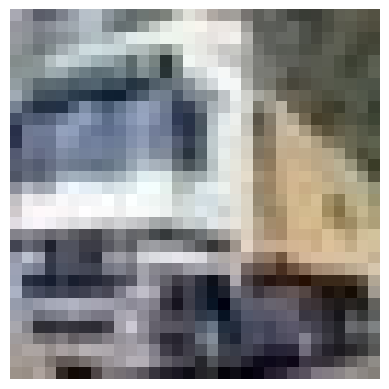

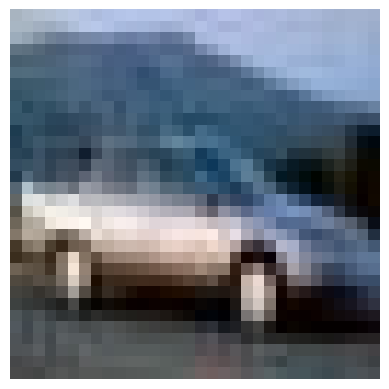

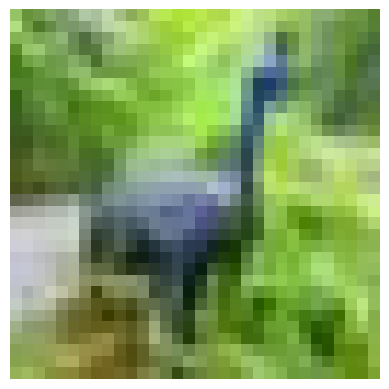

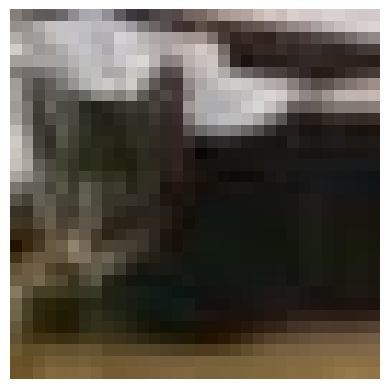

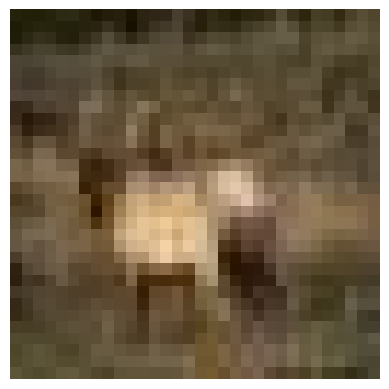

In [ ]:
i = 5
for img_path in os.listdir(os.path.join(data_dir, train, 'REAL')):
  if i ==0 :
    break
  i -= 1
  img = mpimg.imread(os.path.join(data_dir, train, 'REAL',img_path))
  imgplot = plt.imshow(img)
  plt.axis('off')
  plt.show()

- Função de reorganização das pastas do conjunto de dados

In [ ]:
def transform_cls(root):
    for cls in os.listdir(root):
        for i, img in enumerate(os.listdir(os.path.join(root, cls))):
            new_name = f"{cls.lower()}_{i}.jpg"  # Nome único baseado no índice
            os.rename(os.path.join(root, cls, img), os.path.join(root, new_name))

- Chamada de função para as imagens de treino

In [ ]:
transform_cls(os.path.join(data_dir, train))

- Chamada de função para as imagens de teste

In [ ]:
transform_cls(os.path.join(data_dir, test))

- Função para criar o conjunto de validação a partir do treino

In [ ]:
def make_validation_data(data_dir, train):
    root = os.path.join(data_dir, train)
    val_img_path = []

    for img in os.listdir(root):
        label = img.split('.')[0].split('_')[0]
        if len(val_img_path) < 10000 and label == 'fake':
            val_img_path.append(os.path.join(root, img))
        elif len(val_img_path) < 20000 and label == 'real':
            val_img_path.append(os.path.join(root, img))

    # Diretório de validação
    val_dir = os.path.join(data_dir, val)
    if not os.path.exists(val_dir):
        os.mkdir(val_dir)

    # Mover as imagens para o diretório de validação
    for img_path in val_img_path:
        # Extrai o nome completo da imagem, não apenas a extensão
        img_name = os.path.basename(img_path)
        os.rename(img_path, os.path.join(val_dir, img_name))


- Chamada de função

In [ ]:
make_validation_data(data_dir, train)

- Classe das Imagens do Dataset
  - FAKE = 0
  - REAL = 1

- Função de criação do dataset personalizado

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, img_dir: str, transform=None, sample_size=0.3):
        self.img_dir = img_dir
        self.transform = transform

        # Filtrar para incluir apenas arquivos e ignorar diretórios
        self.image_paths = [f for f in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, f))]
        amostras = int(len(self.image_paths)*sample_size)
        self.image_paths[:amostras]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_paths[idx])
        image = Image.open(img_path)

        # Extrair o rótulo do nome da imagem
        label_str = self.image_paths[idx].split('_')[0]

        if label_str == 'fake':
            label = torch.tensor(0)
        else:
            label = torch.tensor(1)

        if self.transform:
            image = self.transform(image)

        return image, label

## Inferência Inicial

### Preparação do modelo

- Define os pesos default para o modelo (pré-treinado)

In [ ]:
weights_pre = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights_pre)

- Determina o número de classes e cria as camadas fully-conected

In [ ]:
num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes)

- Faz usar GPU, senão CPU

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

- Redimensionamento das imagens ocorre por interpolação

In [ ]:
# Definindo as transformações (Redimensionamento e conversão para tensor)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Tamanho esperado pelo ResNet50
    transforms.PILToTensor(),  # Converte a imagem para tensor não normalizado
])

- Customiza as imagens de treino novamente para as novas transformações e carrega o dataloader de teste

In [ ]:
test_dataset_pre = CustomImageDataset(os.path.join(data_dir, test), transform)
test_dataloader_pre = DataLoader(test_dataset_pre, batch_size=64, shuffle=True) # fornece os dados em lotes e embaralha as amostras

- Cria uma função para rodar a inferência

In [ ]:
def run_inference(model, dataloader, device):
    model.eval()  # Garantir que o modelo esteja em modo de avaliação
    all_preds = [] # lista de previsões
    all_labels = [] # lista de labels para cada previsão

    with torch.no_grad():  # Não vamos calcular gradientes durante a inferência
        for images, labels in dataloader:
            images = images.to(device).float() # converte os tensores de imagens para float
            labels = labels.to(device)
            # Fazer a inferência
            outputs = model(images) # Passa as imagens pelo modelo e calcula as saídas

            # Pegar as previsões (o índice com a maior probabilidade)
            _, preds = torch.max(outputs, 1)

            # Guardar previsões e rótulos
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_preds), torch.cat(all_labels)

- Execução da inferência inicial

In [ ]:
test_preds_inf, test_labels_inf = run_inference(model, test_dataloader_pre, device)

- Mostrar o tamanho das previsões e rótulos para validação

In [ ]:
print(f'Previsões para {len(test_preds_inf)} imagens.')
print(f'Primeiras previsões: {test_preds_inf[:10]}')
print(f'Primeiros rótulos: {test_labels_inf[:10]}')

Previsões para 20000 imagens.
Primeiras previsões: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Primeiros rótulos: tensor([0, 1, 1, 1, 1, 1, 0, 0, 1, 1])


- Métricas utilizadas: accuracy, precision, recall, f1-score e a matriz de confusão

In [ ]:
def compute_metrics(preds, labels):
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    cm = confusion_matrix(labels, preds)

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Confusion Matrix: \n{cm}")

    return accuracy, precision, recall, f1, cm

- Mostrar as métricas para o conjunto de teste sem o fine Tuning

In [ ]:
accuracy_inf, precision_inf, recall_inf, f1_inf, cm_inf = compute_metrics(test_preds_inf.cpu(), test_labels_inf.cpu())

Accuracy: 0.4842
Precision: 0.38433382137628114
Recall: 0.0525
F1-Score: 0.09238078479676227
Confusion Matrix: 
[[9159  841]
 [9475  525]]


## Fine Tuning

- Congelar camadas iniciais e deixar a camada totalmente conectada treinável

In [ ]:
# Congelar todas as camadas convolucionais
for param in model.parameters():
    param.requires_grad = False

# Deixar a camada totalmente conectada (fc) treinável
for param in model.fc.parameters():
    param.requires_grad = True

- Transformações
  - Reajuste do tamanho das imagens
  - Conversão para Tensor

In [ ]:
# Transforma as imagens de acordo com os requisitos do modelo
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Tamanho padrão para ResNet
    transforms.PILToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalização usada para ImageNet
])

### Ajuste de Hyper parâmetros

- Criação de conjuntos de dados para ajuste de hiperparâmetros com 30% de amostras

In [ ]:
temp_train_dataset = CustomImageDataset(os.path.join(data_dir, train), transform)
temp_val_dataset = CustomImageDataset(os.path.join(data_dir, val), transform)
temp_test_dataset = CustomImageDataset(os.path.join(data_dir, test), transform)

- Criação de dataloaders com os conjuntos de dados para ajuste de hiperparâmetros com 30% de amostras

In [ ]:
temp_train_dataloader = DataLoader(temp_train_dataset, batch_size=64, shuffle=True)
temp_val_dataloader = DataLoader(temp_val_dataset, batch_size=64, shuffle=True)
temp_test_dataloader = DataLoader(temp_test_dataset, batch_size=64, shuffle=True)

- Dicionário de combinações de parâmetros com otimizadores

In [ ]:
# Definir o otimizador
optimizers_30 = {'Adam-0.1': {'optim': optim.Adam(model.fc.parameters(), lr=0.1), 'Training loss': None, 'Train time': None, 'Val Accuracy':None}, # Otimizar apenas a camada 'fc'
              'Adam-0.01': {'optim': optim.Adam(model.fc.parameters(), lr=0.01), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'Adam-0.001': {'optim': optim.Adam(model.fc.parameters(), lr=0.001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'Adam-0.0001': {'optim': optim.Adam(model.fc.parameters(), lr=0.0001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'AdaGrad-0.1': {'optim': optim.Adagrad(model.fc.parameters(), lr=0.1), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'AdaGrad-0.01': {'optim': optim.Adagrad(model.fc.parameters(), lr=0.01), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'AdaGrad-0.001': {'optim': optim.Adagrad(model.fc.parameters(), lr=0.001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'AdaGrad-0.0001': {'optim': optim.Adagrad(model.fc.parameters(), lr=0.0001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'RMSprop-0.1': {'optim': optim.RMSprop(model.fc.parameters(), lr=0.1), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'RMSprop-0.01': {'optim': optim.RMSprop(model.fc.parameters(), lr=0.01), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'RMSprop-0.001': {'optim': optim.RMSprop(model.fc.parameters(), lr=0.001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'RMSprop-0.0001': {'optim': optim.RMSprop(model.fc.parameters(), lr=0.0001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'SGD-0.1': {'optim': optim.SGD(model.fc.parameters(), lr=0.1), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'SGD-0.01': {'optim': optim.SGD(model.fc.parameters(), lr=0.01), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'SGD-0.001': {'optim': optim.SGD(model.fc.parameters(), lr=0.001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
              'SGD-0.0001': {'optim': optim.SGD(model.fc.parameters(), lr=0.0001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None}
             }

- Função de Perda

In [ ]:
# Definir a função de perda
criterion = nn.CrossEntropyLoss()

- Definir o dispositivo de execução, GPU se disponível

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_30 = model
model_30 = model_30.to(device)

- Função de avaliação do modelo

In [ ]:
def evaluate_model(model, dataloader, device):
    preds, labels = run_inference(model, dataloader, device)
    return accuracy_score(labels, preds)

- Execução do loop de treinamento

In [ ]:
# Função de treinamento com avaliação no conjunto de validação
def train_and_evaluate(model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs, device):
    model = model.to(device)
    train_losses = []  # Armazenar a perda de cada época
    val_accuracy = []

    for epoch in range(num_epochs): # percorre todas as épocas
        model.train()  # Colocar o modelo em modo de treinamento
        running_loss = 0.0

        for images, labels in train_dataloader:
            images = images.to(device).float()
            labels = labels.to(device)

            optimizer.zero_grad()  # Limpar gradientes
            outputs = model(images)  # Fazer a inferência
            loss = criterion(outputs, labels)  # Calcular a perda
            loss.backward()  # Backpropagation
            optimizer.step()  # Atualizar os pesos

            running_loss += loss.item() # acumula a perda

        train_loss = running_loss / len(train_dataloader) # cálculo da perda total do treino
        train_losses.append(train_loss)  # Armazenar a perda da época

        # Avaliar o modelo no conjunto de validação
        accuracy = evaluate_model(model, val_dataloader, device)
        val_accuracy.append(accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

    return train_losses, val_accuracy

- Execução do ajuste de hiperparâmetros com 30% do dataset para definir o melhor otimizador

In [ ]:
# Chamando a função de treinamento e avaliação
def call_tunning_params(model, optimizers, train_dataloader, val_dataloader, num_epochs):
    for param in optimizers:
        start = timeit.default_timer()
        print(f'----{param}----')
        train_losses, val_acc = train_and_evaluate(model, train_dataloader, val_dataloader, criterion, optimizers[param]['optim'], num_epochs=num_epochs, device=device)
        print('---------------')
        stop = timeit.default_timer()
        optimizers[param]['Training loss'] = train_losses
        optimizers[param]['Val Accuracy'] = val_acc
        optimizers[param]['Train time'] = stop - start

    return optimizers

In [ ]:
optimizers_30 = call_tunning_params(model_30, optimizers_30, temp_train_dataloader, temp_val_dataloader, 5)

----Adam-0.1----
Epoch 1/5, Training Loss: 1.4239, Validation Accuracy: 0.8838
Epoch 2/5, Training Loss: 1.6755, Validation Accuracy: 0.8858
Epoch 3/5, Training Loss: 1.6461, Validation Accuracy: 0.8774
Epoch 4/5, Training Loss: 1.6088, Validation Accuracy: 0.8811
Epoch 5/5, Training Loss: 1.7034, Validation Accuracy: 0.8646
---------------
----Adam-0.01----
Epoch 1/5, Training Loss: 0.9654, Validation Accuracy: 0.8930
Epoch 2/5, Training Loss: 0.7079, Validation Accuracy: 0.8929
Epoch 3/5, Training Loss: 0.5571, Validation Accuracy: 0.8936
Epoch 4/5, Training Loss: 0.4472, Validation Accuracy: 0.8893
Epoch 5/5, Training Loss: 0.3943, Validation Accuracy: 0.8884
---------------
----Adam-0.001----
Epoch 1/5, Training Loss: 0.2890, Validation Accuracy: 0.8984
Epoch 2/5, Training Loss: 0.2752, Validation Accuracy: 0.8981
Epoch 3/5, Training Loss: 0.2649, Validation Accuracy: 0.8992
Epoch 4/5, Training Loss: 0.2615, Validation Accuracy: 0.8995
Epoch 5/5, Training Loss: 0.2541, Validation A

- Variáveis para mostrar o relatório de resultados

In [ ]:
lr_30_used = ['0.1', '0.01', '0.001', '0.0001']
optimizers_30_used = ['Adam', 'AdaGrad', 'RMSprop', 'SGD']

- Função para reorganizar os resultados para mostrar no relatório

In [ ]:
def make_results(optimizers_dict, lr_used, optimizers_used):
    loss_data = {}
    accuracy_data = {}

    for optim in optimizers_used:
        loss_data[optim] = {}
        accuracy_data[optim] = {}

        for lr in lr_used:
            id_optim = f'{optim}-{lr}'
            loss_data[optim].update({f'lr-{lr}':optimizers_dict[id_optim]['Training loss']})
            accuracy_data[optim].update({f'lr-{lr}':optimizers_dict[id_optim]['Val Accuracy']})

    return loss_data, accuracy_data

In [ ]:
loss_30_data, accuracy_30_data = make_results(optimizers_30, lr_30_used, optimizers_30_used)

In [ ]:
pprint.pp(loss_30_data)
pprint.pp(accuracy_30_data)

{'Adam': {'lr-0.1': [1.4239369526147843,
                     1.6755284711271525,
                     1.6461291153788566,
                     1.6087539996504783,
                     1.703378760677576],
          'lr-0.01': [0.9654493765294552,
                      0.7079436356693506,
                      0.5571391674250364,
                      0.4471664995580912,
                      0.3942851819187403],
          'lr-0.001': [0.2889817016094923,
                       0.27519042793810367,
                       0.26489811470508573,
                       0.2614870334029198,
                       0.25411552579700947],
          'lr-0.0001': [0.24525972993671893,
                        0.2423143842190504,
                        0.24474614213705062,
                        0.24184155283272266,
                        0.2405218171864748]},
 'AdaGrad': {'lr-0.1': [0.31581711329221723,
                        0.25707002584934235,
                        0.24533884226679803,
     

- Função de mostrar o relatório de resultados

In [ ]:
def show_results(accuracy_data, loss_data, lr_used, optimizers_used, num_epocs):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    epochs = range(1, num_epocs+1)

    for i, lr in enumerate(lr_used):
        ax = axes[0, i]

        for optim in optimizers_used:
            ax.plot(epochs, loss_data[optim][f'lr-{lr}'], label=optim)

        ax.set_title(f'Perda - {lr}')
        ax.set_xlabel('Épocas')
        ax.set_ylabel('Perda')
        ax.legend()

    for i, lr in enumerate(lr_used):
        ax = axes[1, i]

        for optim in optimizers_used:
            ax.plot(epochs, accuracy_data[optim][f'lr-{lr}'], label=optim)

        ax.set_title(f'Acurácia - {lr}')
        ax.set_xlabel('Épocas')
        ax.set_ylabel('Acurácia')
        ax.legend()

    plt.tight_layout()
    plt.show()

- Mostrando relatório do ajuste com 30% das amostras

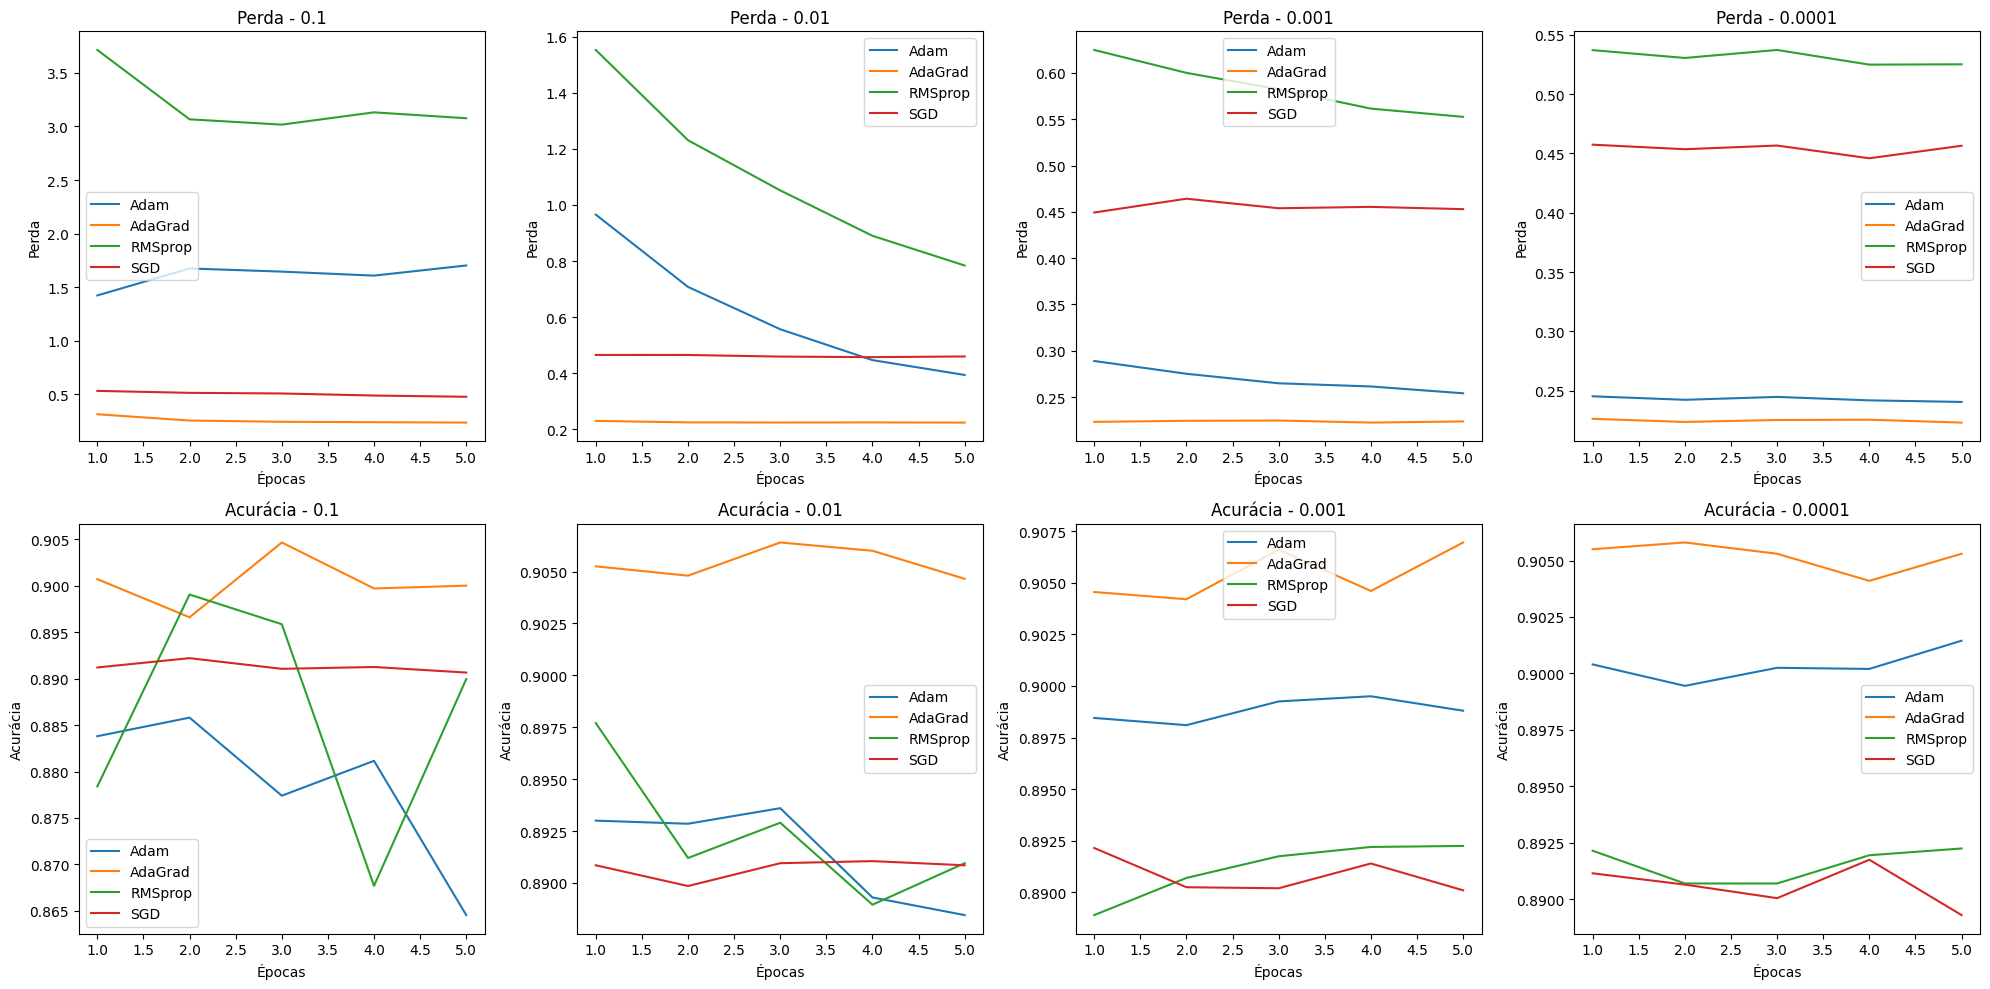

In [ ]:
show_results(accuracy_30_data, loss_30_data, lr_30_used, optimizers_30_used, 5)

### Preparação dos modelos e dos dados pra ajuste de melhor taxa de aprendizado a partir do melhor otimizador

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_50 = model
model_50 = model_50.to(device)

- Criação de novos conjuntos de dados para ajuste de hiperparâmetros com 50% de amostras

In [ ]:
new_temp_train_dataset = CustomImageDataset(os.path.join(data_dir, train), transform, sample_size=0.5)
new_temp_val_dataset = CustomImageDataset(os.path.join(data_dir, val), transform, sample_size=0.5)
new_temp_test_dataset = CustomImageDataset(os.path.join(data_dir, test), transform, sample_size=0.5)

- Criação de dataloaders com os novos conjuntos de dados para ajuste de hiperparâmetros com 50% de amostras

In [ ]:
new_temp_train_dataloader = DataLoader(new_temp_train_dataset, batch_size=64, shuffle=True)
new_temp_val_dataloader = DataLoader(new_temp_val_dataset, batch_size=64, shuffle=True)
new_temp_test_dataloader = DataLoader(new_temp_test_dataset, batch_size=64, shuffle=True)

- Criação do dicionário de parâmetros para o melhor otimizador

In [ ]:
best_optimizer = {'Adam-0.1': {'optim': optim.Adam(model.fc.parameters(), lr=0.1), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
                  'Adam-0.01': {'optim': optim.Adam(model.fc.parameters(), lr=0.01), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
                  'Adam-0.001': {'optim': optim.Adam(model.fc.parameters(), lr=0.001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None},
                  'Adam-0.0001': {'optim': optim.Adam(model.fc.parameters(), lr=0.0001), 'Training loss': None, 'Train time': None, 'Val Accuracy':None}}

In [ ]:
lr_50_used = ['0.1', '0.01', '0.001', '0.0001']
optimizers_50_used = ['Adam']

- Execução da otimização de hiperparâmetros para definir a melhor taxa de aprendizado

In [ ]:
best_optimizer = call_tunning_params(model_50, best_optimizer, new_temp_train_dataloader, new_temp_val_dataloader, 10)

----Adam-0.1----
Epoch 1/10, Training Loss: 1.5420, Validation Accuracy: 0.8763
Epoch 2/10, Training Loss: 1.5923, Validation Accuracy: 0.8825
Epoch 3/10, Training Loss: 1.7151, Validation Accuracy: 0.8770
Epoch 4/10, Training Loss: 1.6528, Validation Accuracy: 0.8735
Epoch 5/10, Training Loss: 1.6817, Validation Accuracy: 0.8284
Epoch 6/10, Training Loss: 1.7141, Validation Accuracy: 0.8859
Epoch 7/10, Training Loss: 1.7420, Validation Accuracy: 0.8005
Epoch 8/10, Training Loss: 1.6219, Validation Accuracy: 0.8722
Epoch 9/10, Training Loss: 1.7876, Validation Accuracy: 0.8687
Epoch 10/10, Training Loss: 1.7579, Validation Accuracy: 0.8825
---------------
----Adam-0.01----
Epoch 1/10, Training Loss: 0.9714, Validation Accuracy: 0.8913
Epoch 2/10, Training Loss: 0.7237, Validation Accuracy: 0.8930
Epoch 3/10, Training Loss: 0.5806, Validation Accuracy: 0.8854
Epoch 4/10, Training Loss: 0.4758, Validation Accuracy: 0.8922
Epoch 5/10, Training Loss: 0.4024, Validation Accuracy: 0.8908
Epo

- Chamada da função para reorganizar os resultados para mostrar no relatório

In [ ]:
loss_50_data, accuracy_50_data = make_results(best_optimizer, lr_50_used, optimizers_50_used)

In [ ]:
print(loss_50_data)
print(accuracy_50_data)

{'Adam': {'lr-0.1': [1.5420266891121863, 1.592329247802496, 1.715128639614582, 1.652754018086195, 1.6816666765742003, 1.7140750860214233, 1.7420415382623673, 1.6218559544980526, 1.7876408230423928, 1.757935666024685], 'lr-0.01': [0.9713722642123699, 0.7236727280668914, 0.5806077965199947, 0.47580763860046865, 0.4024279618769884, 0.35198278816342354, 0.31805568605065343, 0.3215942001640797, 0.3075172934889793, 0.31079824796617034], 'lr-0.001': [0.2530207081258297, 0.2421985343515873, 0.23958893561661243, 0.23692227880060673, 0.232501148635149, 0.23367185642719268, 0.23124510544538499, 0.2315787653476, 0.2297976084113121, 0.22870008160471916], 'lr-0.0001': [0.2218937471449375, 0.22561265857815743, 0.2231325408667326, 0.2220692843914032, 0.2218074619412422, 0.22145767903327943, 0.22234359993934633, 0.22137102229595185, 0.22201170326471328, 0.22386067533791065]}}
{'Adam': {'lr-0.1': [0.87635, 0.88255, 0.87695, 0.8735, 0.82835, 0.8859, 0.80055, 0.8722, 0.8687, 0.88255], 'lr-0.01': [0.89135,

- Mostrando relatório do ajuste com 50% das amostras

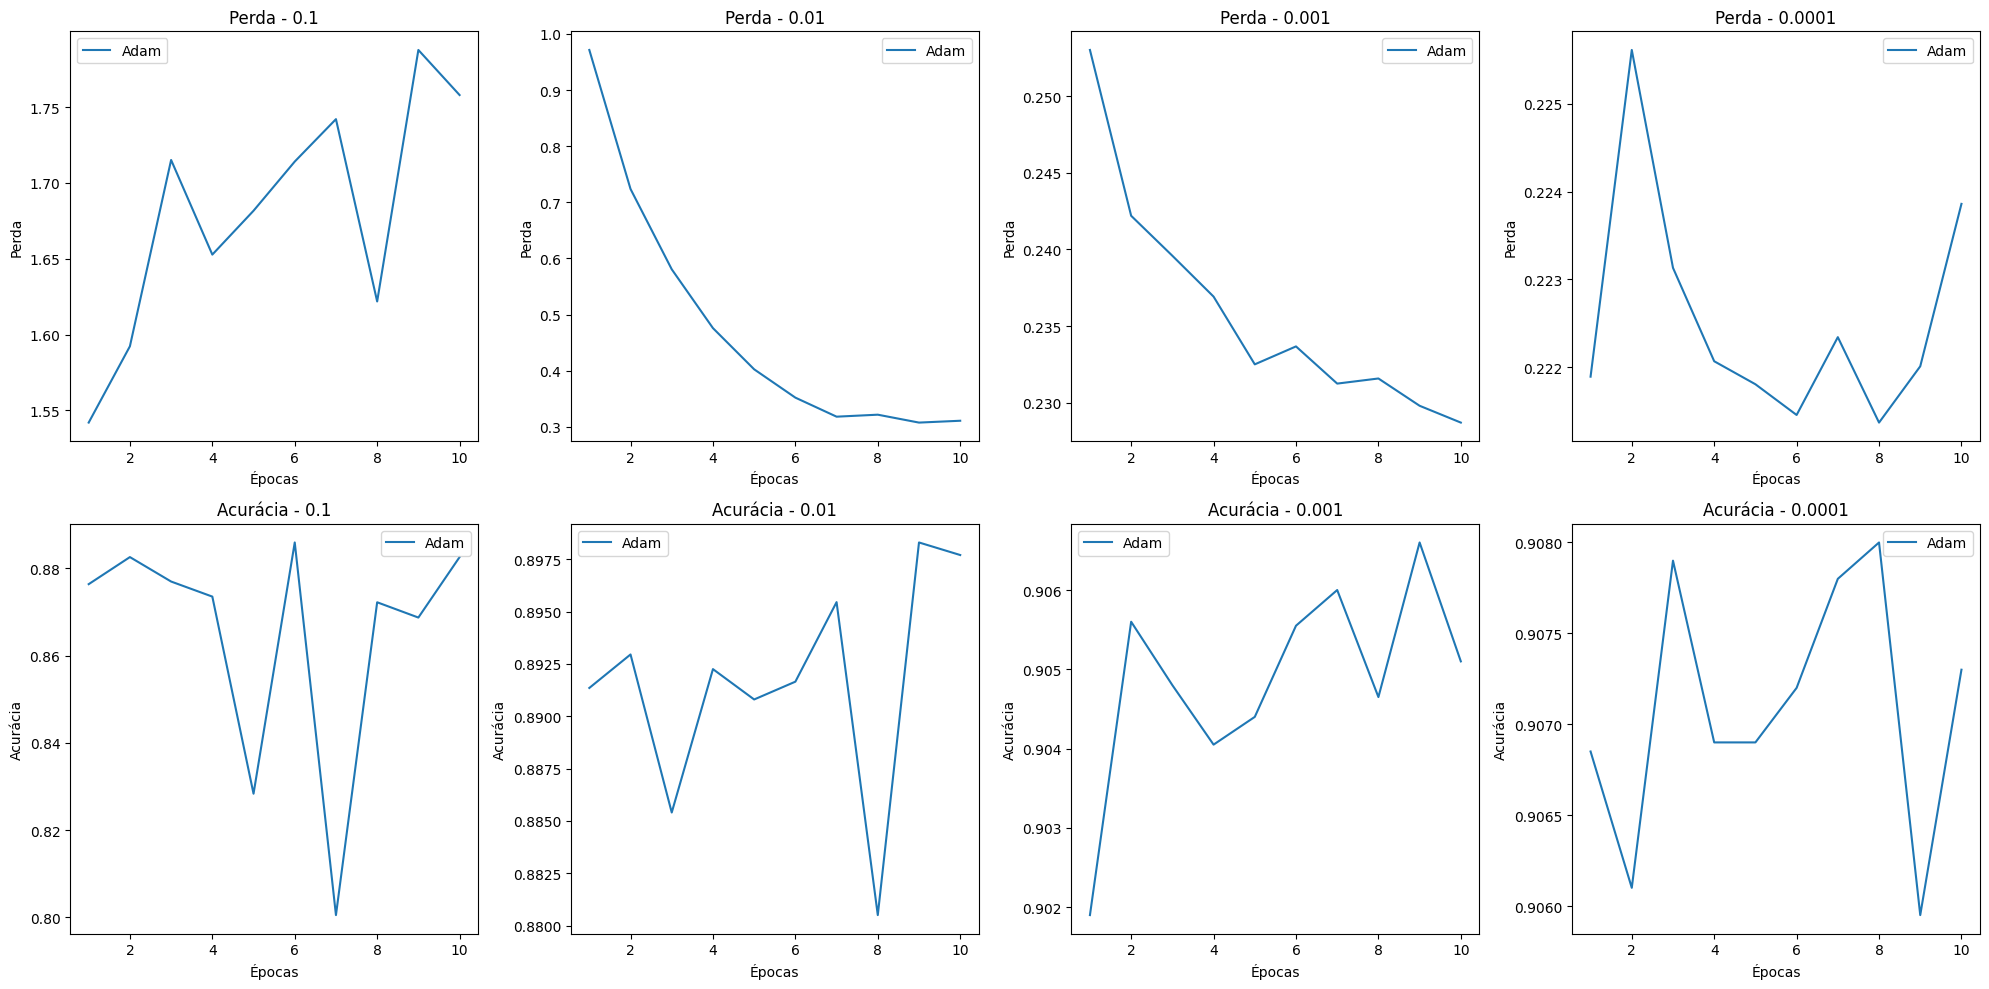

In [ ]:
show_results(accuracy_50_data, loss_50_data, lr_50_used, optimizers_50_used, 10)

### Treinamento com os melhores parâmetros

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_full = model
model_full = model_full.to(device)

In [ ]:
best_optim = optim.Adam(model.fc.parameters(), lr=0.0001)

- Criação de novos conjuntos de dados para ajuste de hiperparâmetros com 100% de amostras

In [ ]:
train_dataset = CustomImageDataset(os.path.join(data_dir, train), transform, sample_size=1)
val_dataset = CustomImageDataset(os.path.join(data_dir, val), transform, sample_size=1)
test_dataset = CustomImageDataset(os.path.join(data_dir, test), transform, sample_size=1)

- Criação de dataloaders com os novos conjuntos de dados para ajuste de hiperparâmetros com 100% de amostras

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

- Treino do modelo com todos os dados

In [ ]:
train_losses, val_acc = train_and_evaluate(model_full, train_dataloader, val_dataloader, criterion, best_optim, num_epochs=10, device=device)

Epoch 1/10, Training Loss: 0.2232, Validation Accuracy: 0.9065
Epoch 2/10, Training Loss: 0.2216, Validation Accuracy: 0.9069
Epoch 3/10, Training Loss: 0.2209, Validation Accuracy: 0.9076
Epoch 4/10, Training Loss: 0.2221, Validation Accuracy: 0.9084
Epoch 5/10, Training Loss: 0.2213, Validation Accuracy: 0.9069
Epoch 6/10, Training Loss: 0.2219, Validation Accuracy: 0.9061
Epoch 7/10, Training Loss: 0.2211, Validation Accuracy: 0.9073
Epoch 8/10, Training Loss: 0.2224, Validation Accuracy: 0.9075
Epoch 9/10, Training Loss: 0.2200, Validation Accuracy: 0.9073
Epoch 10/10, Training Loss: 0.2234, Validation Accuracy: 0.9056


- Gráfico de perda

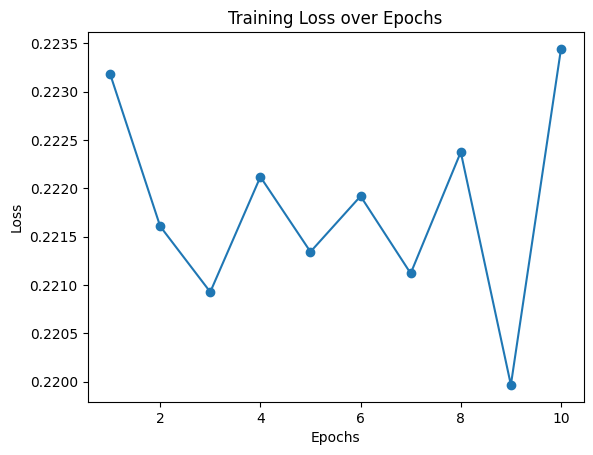

In [ ]:
plt.plot(range(1, 11), train_losses, marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

- Gráfico de acurácia

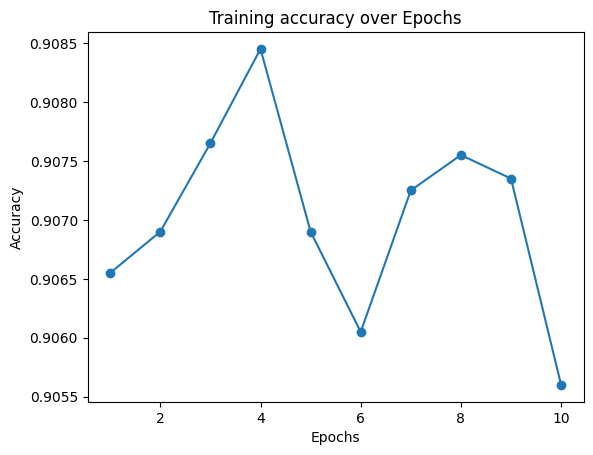

In [ ]:
plt.plot(range(1, 11), val_acc, marker='o')
plt.title('Training accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Avaliação do modelo final

Métricas utilizadas: accuracy, precision, recall, f1-score e a matriz de confusão

- Execução do modelo treinado para o conjunto de teste

In [ ]:
test_preds, test_labels = run_inference(model_full, test_dataloader, device)

- Métricas

In [ ]:
accuracy, precision, recall, f1, cm = compute_metrics(test_preds.cpu(), test_labels.cpu())

Accuracy: 0.91045
Precision: 0.9249404700279532
Recall: 0.8934
F1-Score: 0.9088966885396002
Confusion Matrix: 
[[9275  725]
 [1066 8934]]


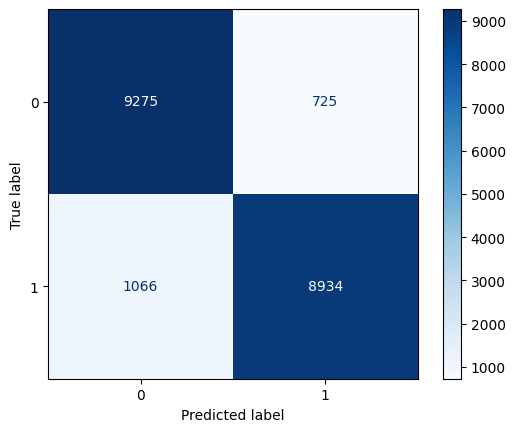

In [ ]:
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
def show_incorrect_predictions(dataset, labels, preds, subset):
    dict_labels = {0: 'fake', 1: 'real'}
    for id, image in enumerate(Subset(dataset, subset)):
        if labels[id] != preds[id]:
            plt.imshow(image[0].permute(1, 2, 0))
            plt.title(f'True: {dict_labels[int(labels[id])]}, Predicted: {dict_labels[int(preds[id])]}')
            plt.show()

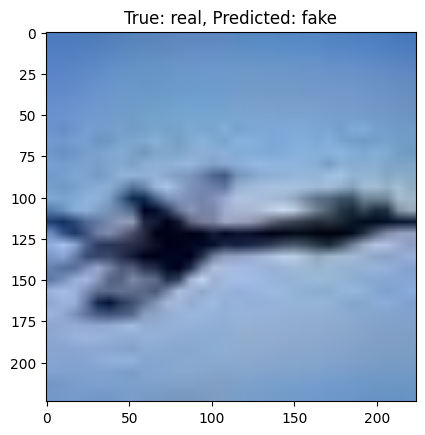

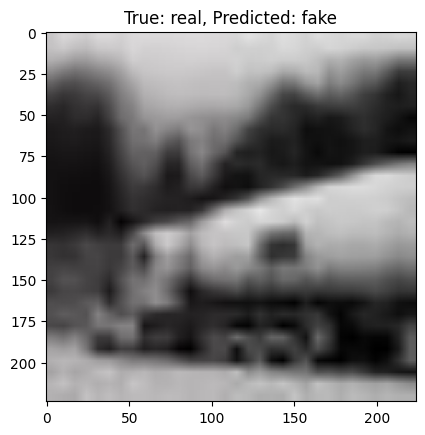

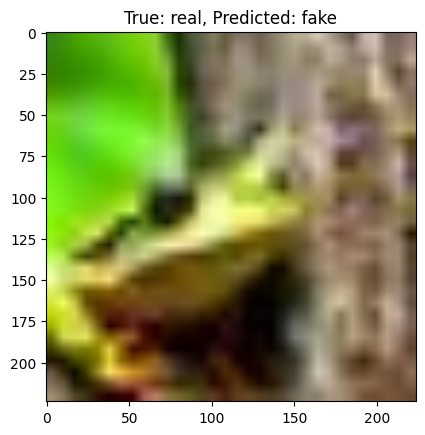

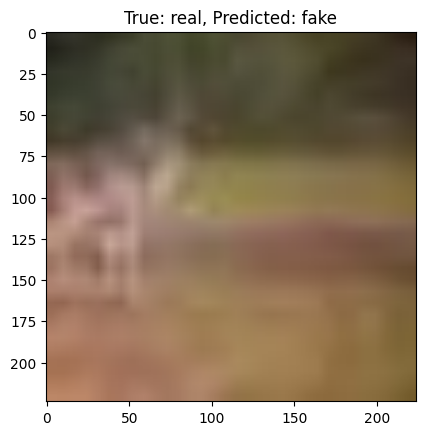

In [ ]:
show_incorrect_predictions(test_dataset, test_labels, test_preds, list(range(50)))

## Evolução do modelo base para o modelo final

In [ ]:
modelos = {
    'Inicial': {
        'accuracy': accuracy_inf,
        'precision': precision_inf,
        'recall': recall_inf,
        'f1-score': f1_inf
    },
    'Ajustado': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1
    }
}

modelos_df = pd.DataFrame(modelos)
modelos_df

,Inicial,Ajustado
accuracy,0.484200,0.910450
precision,0.384334,0.924940
recall,0.052500,0.893400
f1-score,0.092381,0.908897


### Comparativo entre métricas modelo inicial vs ajustado

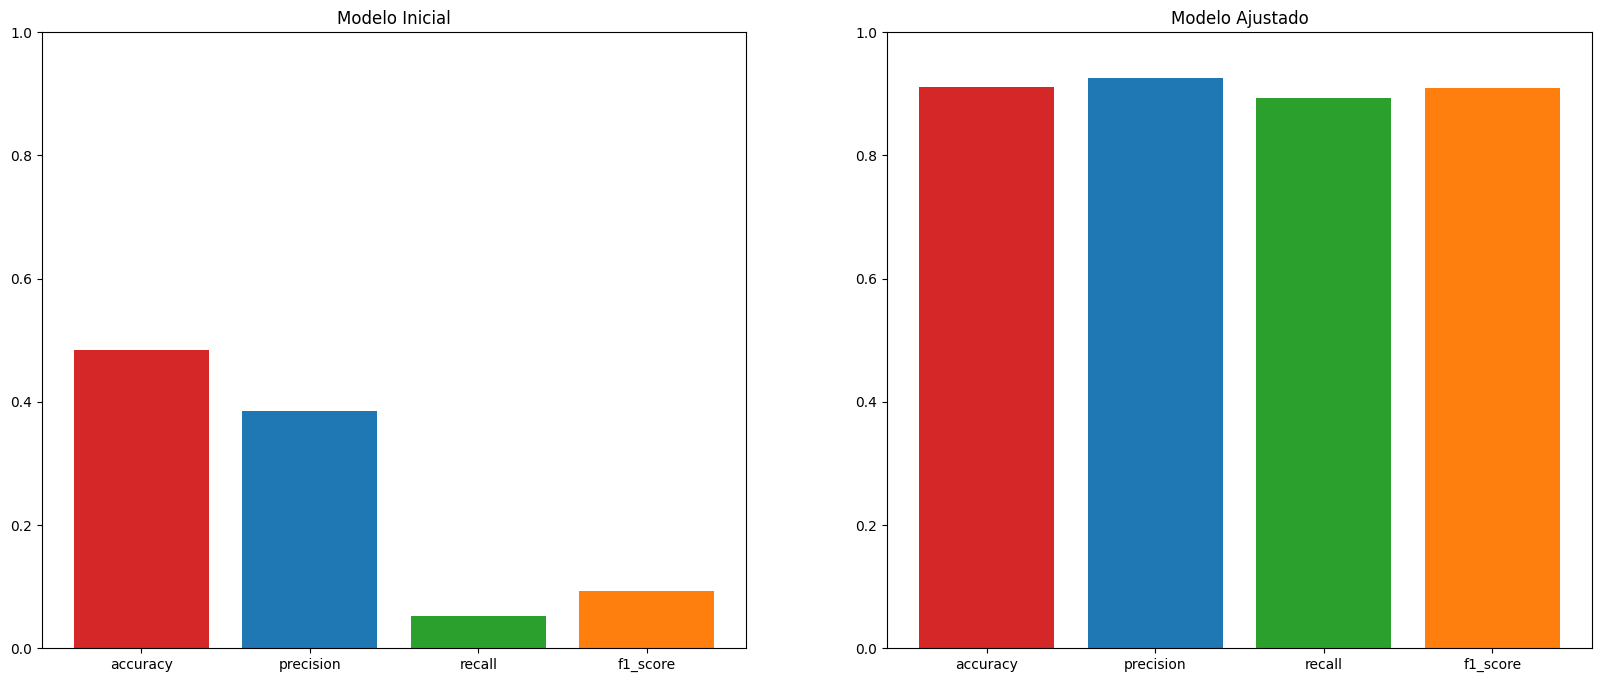

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
values_inicial = modelos_df['Inicial']
values_ajustado = modelos_df['Ajustado']
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']

axes[0].set_title('Modelo Inicial')
axes[0].bar(metrics, values_inicial, color=colors)
axes[0].set_ylim(0, 1)
axes[1].set_title('Modelo Ajustado')
axes[1].bar(metrics, values_ajustado, color=colors)
axes[1].set_ylim(0, 1)
plt.show()